In [38]:
import matplotlib.pyplot as plt
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point
import pandas as pd

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

# 교통 지수

## 버스, 따릉이, 지하철 데이터 로드 및 좌표 변환

In [39]:
# 버스정류장 데이터 로드
df_bus = pd.read_csv("서울시 버스정류소 위치정보.csv", encoding='cp949')
df_bus = df_bus.rename(columns = {"X좌표": "경도", "Y좌표": "위도"})
display(df_bus.head())

# 좌표를 Point로 변환
# SGIS 행정동 경계 좌표계 UTM-K(GRS80타원체)는 crs: EPSG:5179
df_bus["geometry"] = df_bus.apply(lambda x: Point(x["경도"], x["위도"]), axis = 1)
geo_bus = GeoDataFrame(df_bus, crs = "EPSG:5179", geometry = "geometry")
display(geo_bus.head())

,노드 ID,정류소번호,정류소명,경도,위도,정류소 타입
0,100000001,1001,종로2가사거리,126.987752,37.569808,중앙차로
1,100000002,1002,창경궁.서울대학교병원,126.996522,37.579433,중앙차로
2,100000003,1003,명륜3가.성대입구,126.998251,37.582581,중앙차로
3,100000004,1004,종로2가.삼일교,126.987613,37.568579,중앙차로
4,100000005,1005,혜화동로터리.여운형활동터,127.001744,37.586243,중앙차로


,노드 ID,정류소번호,정류소명,경도,위도,정류소 타입,geometry
0,100000001,1001,종로2가사거리,126.987752,37.569808,중앙차로,POINT (126.988 37.57)
1,100000002,1002,창경궁.서울대학교병원,126.996522,37.579433,중앙차로,POINT (126.997 37.579)
2,100000003,1003,명륜3가.성대입구,126.998251,37.582581,중앙차로,POINT (126.998 37.583)
3,100000004,1004,종로2가.삼일교,126.987613,37.568579,중앙차로,POINT (126.988 37.569)
4,100000005,1005,혜화동로터리.여운형활동터,127.001744,37.586243,중앙차로,POINT (127.002 37.586)


In [40]:
# 따릉이대여소 데이터 로드
df_bike = pd.read_csv("서울시 따릉이대여소 마스터 정보.csv", encoding='cp949')
df_bike = df_bike[df_bike['위도']!=0]
df_bike = df_bike.rename(columns = {"X좌표": "경도", "Y좌표": "위도"})
display(df_bike.head())

# 좌표를 Point로 변환
# SGIS 행정동 경계 좌표계 UTM-K(GRS80타원체)는 crs: EPSG:5179
df_bike["geometry"] = df_bike.apply(lambda x: Point(x["경도"], x["위도"]), axis = 1)
geo_bike = GeoDataFrame(df_bike, crs = "EPSG:5179", geometry = "geometry")
display(geo_bike.head())

,대여소_ID,주소1,주소2,위도,경도
2,ST-997,서울특별시 양천구 목동중앙로 49,목동3단지 시내버스정류장,37.534390,126.869598
3,ST-996,서울특별시 양천구 남부순환로88길5-16,양강중학교앞 교차로,37.524334,126.850548
4,ST-995,서울특별시 양천구 중앙로 153 공중화장실,NaN,37.510597,126.857323
5,ST-994,서울특별시 양천구 목동서로161,SBS방송국,37.529163,126.872749
6,ST-993,서울특별시 양천구 신월로 342-1 구두수선대19,NaN,37.521511,126.857384


,대여소_ID,주소1,주소2,위도,경도,geometry
2,ST-997,서울특별시 양천구 목동중앙로 49,목동3단지 시내버스정류장,37.534390,126.869598,POINT (126.87 37.534)
3,ST-996,서울특별시 양천구 남부순환로88길5-16,양강중학교앞 교차로,37.524334,126.850548,POINT (126.851 37.524)
4,ST-995,서울특별시 양천구 중앙로 153 공중화장실,NaN,37.510597,126.857323,POINT (126.857 37.511)
5,ST-994,서울특별시 양천구 목동서로161,SBS방송국,37.529163,126.872749,POINT (126.873 37.529)
6,ST-993,서울특별시 양천구 신월로 342-1 구두수선대19,NaN,37.521511,126.857384,POINT (126.857 37.522)


In [41]:
# 지하철 데이터 로드
df_metro = pd.read_csv("서울시 역사마스터 정보.csv", encoding='cp949')
df_metro = df_metro.rename(columns = {"X좌표": "경도", "Y좌표": "위도"})
display(df_metro.head())

# 좌표를 Point로 변환
# SGIS 행정동 경계 좌표계 UTM-K(GRS80타원체)는 crs: EPSG:5179
df_metro["geometry"] = df_metro.apply(lambda x: Point(x["경도"], x["위도"]), axis = 1)
geo_metro = GeoDataFrame(df_metro, crs = "EPSG:5179", geometry = "geometry")
display(geo_metro.head()) 

,역사_ID,역사명,호선,위도,경도
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569
1,9009,구성,수도권 광역급행철도,37.29913,127.10389
2,9008,성남,수도권 광역급행철도,37.39467,127.12058
3,9007,수서,수도권 광역급행철도,37.48637,127.10161
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324


,역사_ID,역사명,호선,위도,경도,geometry
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569,POINT (127.096 37.2)
1,9009,구성,수도권 광역급행철도,37.29913,127.10389,POINT (127.104 37.299)
2,9008,성남,수도권 광역급행철도,37.39467,127.12058,POINT (127.121 37.395)
3,9007,수서,수도권 광역급행철도,37.48637,127.10161,POINT (127.102 37.486)
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324,POINT (127.063 37.509)


## 서울 500m 격자 불러오기 

In [42]:
geo_shp = gpd.read_file("seoul_grid_500m.shp")

print(f"파일 로드 후 초기 좌표계: {geo_shp.crs}")
print(geo_shp.head())

파일 로드 후 초기 좌표계: EPSG:4326
            cx           cy                                           geometry
0  179439.7616  450297.4067  POLYGON ((126.7645 37.54971, 126.76449 37.5542...
1  179439.7616  450797.4067  POLYGON ((126.76449 37.55422, 126.76447 37.558...
2  179939.7616  449797.4067  POLYGON ((126.77017 37.54522, 126.77016 37.549...
3  179939.7616  450297.4067  POLYGON ((126.77016 37.54972, 126.77015 37.554...
4  179939.7616  450797.4067  POLYGON ((126.77015 37.55423, 126.77013 37.558...


## 경사값 가져오기

In [43]:
slope_shp = gpd.read_file("slope_seoul.shp")

print(f"파일 로드 후 초기 좌표계: {slope_shp.crs}")
slope_shp.head()

파일 로드 후 초기 좌표계: EPSG:4326


,cx,cy,slope_mean,geometry
0,179439.7616,450297.4067,18.125252,"POLYGON ((126.7645 37.54971, 126.76449 37.5542..."
1,179439.7616,450797.4067,18.221235,"POLYGON ((126.76449 37.55422, 126.76447 37.558..."
2,179939.7616,449797.4067,0.665497,"POLYGON ((126.77017 37.54522, 126.77016 37.549..."
3,179939.7616,450297.4067,0.144283,"POLYGON ((126.77016 37.54972, 126.77015 37.554..."
4,179939.7616,450797.4067,0.151225,"POLYGON ((126.77015 37.55423, 126.77013 37.558..."


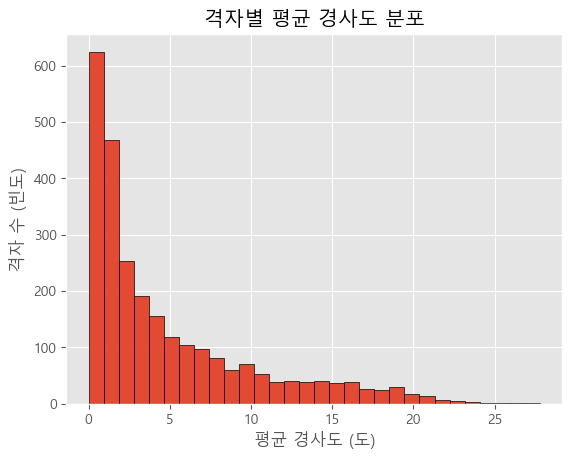

In [ ]:
import matplotlib.pyplot as plt

# Matplotlib의 스타일을 지정하면 더 깔끔해집니다.
plt.style.use('ggplot')

slope_shp['slope_mean'].hist(bins=30, edgecolor='black')

plt.title('격자별 평균 경사도 분포')
plt.xlabel('평균 경사도 (도)')
plt.ylabel('격자 수 (빈도)')
plt.show()

## 격자에 각 정류장/역 수 count (반경 500m <=> 1격자로 통일)

In [45]:
bus = gpd.sjoin(geo_bus, geo_shp)

# 'index_right' 컬럼을 기준으로 그룹화하여 각 그룹의 크기(개수)를 계산합니다.
bus_counts_per_grid = bus.groupby('index_right').size()

# 결과를 보기 좋게 DataFrame으로 변환하고 컬럼 이름을 'bus_count'로 지정합니다.
bus_counts_df = bus_counts_per_grid.to_frame('bus_count').reset_index()

print("--- 격자별 버스정류소 개수 ---")
print(bus_counts_df.head())

--- 격자별 버스정류소 개수 ---
   index_right  bus_count
0            1          2
1           32          2
2           41          2
3           42          1
4           52         11


C:\Users\jeongmin\AppData\Local\Temp\ipykernel_23632\287754335.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:5179
Right CRS: EPSG:4326

  bus = gpd.sjoin(geo_bus, geo_shp)


In [46]:
bike = gpd.sjoin(geo_bike, geo_shp)

# 'index_right' 컬럼을 기준으로 그룹화하여 각 그룹의 크기(개수)를 계산합니다.
bike_counts_per_grid = bike.groupby('index_right').size()

# 결과를 보기 좋게 DataFrame으로 변환하고 컬럼 이름을 'bus_count'로 지정합니다.
bike_counts_df = bike_counts_per_grid.to_frame('bike_count').reset_index()

print("--- 격자별 따릉이 정류소 개수 ---")
print(bike_counts_df.head())

--- 격자별 따릉이 정류소 개수 ---
   index_right  bike_count
0           41           1
1           56           1
2           57           1
3           66           1
4           67           2


C:\Users\jeongmin\AppData\Local\Temp\ipykernel_23632\4105275201.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:5179
Right CRS: EPSG:4326

  bike = gpd.sjoin(geo_bike, geo_shp)


In [47]:
metro = gpd.sjoin(geo_metro, geo_shp)

# 'index_right' 컬럼을 기준으로 그룹화하여 각 그룹의 크기(개수)를 계산합니다.
metro_counts_per_grid = metro.groupby('index_right').size()

# 결과를 보기 좋게 DataFrame으로 변환하고 컬럼 이름을 'bus_count'로 지정합니다.
metro_counts_df = metro_counts_per_grid.to_frame('metro_count').reset_index()

print("--- 격자별 따릉이 정류소 개수 ---")
print(metro_counts_df.head())

--- 격자별 따릉이 정류소 개수 ---
   index_right  metro_count
0           41            1
1           52            4
2           67            1
3           70            1
4           86            1


C:\Users\jeongmin\AppData\Local\Temp\ipykernel_23632\2658088347.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:5179
Right CRS: EPSG:4326

  metro = gpd.sjoin(geo_metro, geo_shp)


In [48]:
slope_shp

,cx,cy,slope_mean,geometry
0,179439.7616,450297.4067,18.125252,"POLYGON ((126.7645 37.54971, 126.76449 37.5542..."
1,179439.7616,450797.4067,18.221235,"POLYGON ((126.76449 37.55422, 126.76447 37.558..."
2,179939.7616,449797.4067,0.665497,"POLYGON ((126.77017 37.54522, 126.77016 37.549..."
3,179939.7616,450297.4067,0.144283,"POLYGON ((126.77016 37.54972, 126.77015 37.554..."
4,179939.7616,450797.4067,0.151225,"POLYGON ((126.77015 37.55423, 126.77013 37.558..."
...,...,...,...,...
2634,215939.7616,451297.4067,0.933832,"POLYGON ((127.17757 37.55882, 127.17758 37.563..."
2635,215939.7616,451797.4067,0.526118,"POLYGON ((127.17758 37.56333, 127.1776 37.5678..."
2636,215939.7616,452297.4067,0.654032,"POLYGON ((127.1776 37.56783, 127.17761 37.5723..."
2637,216439.7616,449297.4067,19.669617,"POLYGON ((127.18319 37.54079, 127.1832 37.5453..."


In [49]:
slope = gpd.sjoin(slope_shp, geo_shp)

# 'index_right' 컬럼을 기준으로 그룹화하여 각 그룹의 크기(개수)를 계산합니다.
slope_counts_per_grid = slope.groupby('index_right').size()

# 결과를 보기 좋게 DataFrame으로 변환하고 컬럼 이름을 'bus_count'로 지정합니다.
slope_counts_df = slope_counts_per_grid.to_frame('slope_count').reset_index()

print("--- 격자별 slope 개수 ---")
print(slope_counts_df.head())

--- 격자별 slope 개수 ---
   index_right  slope_count
0            0            4
1            1            4
2            2            5
3            3            7
4            4            7


In [50]:
# 원본 격자 데이터(geo_shp)와 버스 개수 데이터(bus_counts_df)를 합칩니다.
# 1. 버스 개수 합치기
grid_with_counts = geo_shp.merge(bus_counts_df, left_on=geo_shp.index, right_on='index_right', how='left')
# 불필요해진 index_right 컬럼 삭제
grid_with_counts = grid_with_counts.drop('index_right', axis=1)


# 2. 자전거(따릉이) 개수 합치기
grid_with_counts = grid_with_counts.merge(bike_counts_df, left_on=grid_with_counts.index, right_on='index_right', how='left')
# 다시 불필요해진 index_right 컬럼 삭제
grid_with_counts = grid_with_counts.drop('index_right', axis=1)


# 3. 지하철 개수 합치기
grid_with_counts = grid_with_counts.merge(metro_counts_df, left_on=grid_with_counts.index, right_on='index_right', how='left')
# 마지막으로 불필요해진 index_right 컬럼 삭제
grid_with_counts = grid_with_counts.drop('index_right', axis=1)


# 4. 슬로프 개수 합치기 
grid_with_counts = grid_with_counts.merge(slope_counts_df, left_on=grid_with_counts.index, right_on='index_right', how='left')
# 마지막으로 불필요해진 index_right 컬럼 삭제
grid_with_counts = grid_with_counts.drop('index_right', axis=1)


# 4. (마무리) 새로 생긴 모든 count 컬럼의 NaN 값을 0으로 채우기
count_columns = ['bus_count', 'bike_count', 'metro_count', 'slope_count'] # 실제 컬럼 이름으로 변경해야 합니다.
grid_with_counts[count_columns] = grid_with_counts[count_columns].fillna(0)

grid_with_counts['total_count'] = grid_with_counts[count_columns].sum(axis=1)
grid_with_counts['slope_bike_count'] = grid_with_counts['bike_count']/grid_with_counts['slope_count']


print("\n--- 버스 개수 정보가 합쳐진 최종 격자 데이터 ---")
(grid_with_counts.head())



--- 버스 개수 정보가 합쳐진 최종 격자 데이터 ---


,cx,cy,geometry,bus_count,bike_count,metro_count,slope_count,total_count,slope_bike_count
0,179439.7616,450297.4067,"POLYGON ((126.7645 37.54971, 126.76449 37.5542...",0.0,0.0,0.0,4,4.0,0.0
1,179439.7616,450797.4067,"POLYGON ((126.76449 37.55422, 126.76447 37.558...",2.0,0.0,0.0,4,6.0,0.0
2,179939.7616,449797.4067,"POLYGON ((126.77017 37.54522, 126.77016 37.549...",0.0,0.0,0.0,5,5.0,0.0
3,179939.7616,450297.4067,"POLYGON ((126.77016 37.54972, 126.77015 37.554...",0.0,0.0,0.0,7,7.0,0.0
4,179939.7616,450797.4067,"POLYGON ((126.77015 37.55423, 126.77013 37.558...",0.0,0.0,0.0,7,7.0,0.0


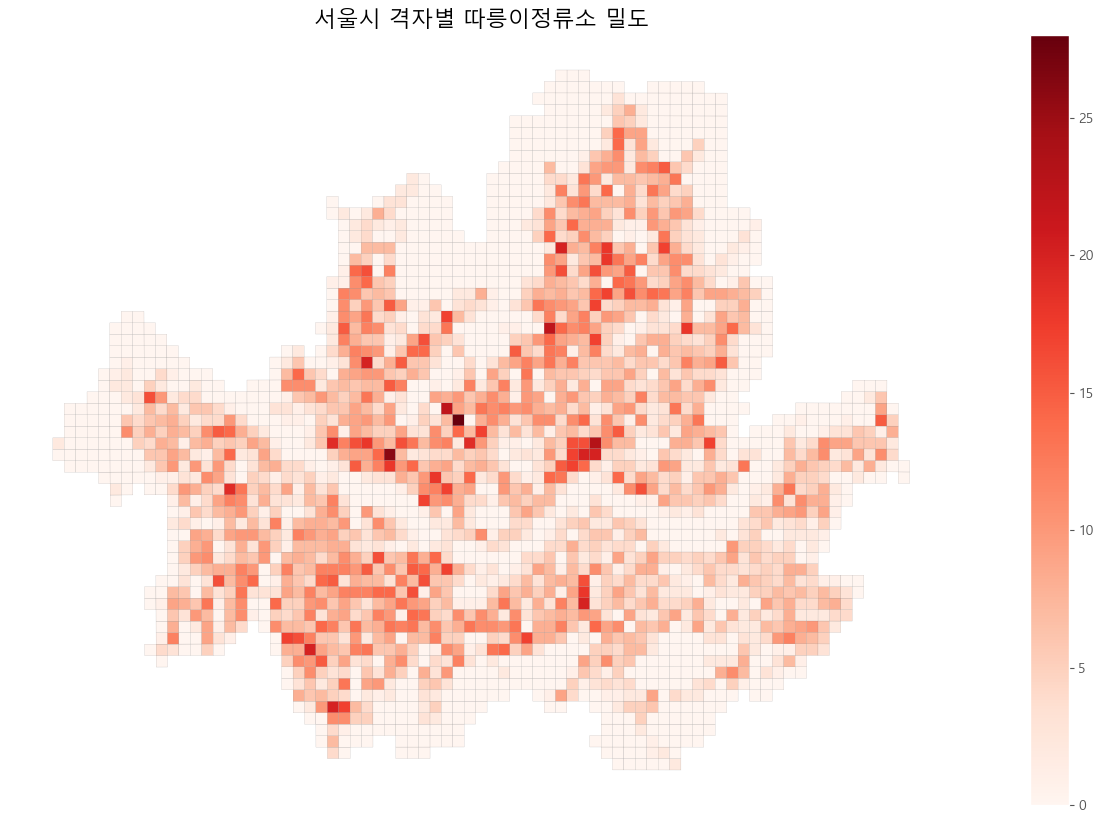

In [51]:
import matplotlib.pyplot as plt

# 시각화를 위한 Figure와 Axes를 준비합니다.
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# 'bus_count' 컬럼의 값에 따라 색상을 다르게 하여 지도를 그립니다.
grid_with_counts.plot(column='bus_count', # 색상을 결정할 기준 컬럼
                      cmap='Reds',      # 사용할 색상 맵 (예: 'Reds', 'Blues', 'Oranges')
                      linewidth=0.1,         # 격자 테두리 선 두께
                      edgecolor='grey',      # 격자 테두리 색상
                      legend=True,           # 범례 표시
                      ax=ax)

# 지도 제목을 추가하고 축은 보이지 않게 처리합니다.
ax.set_title('서울시 격자별 따릉이정류소 밀도', fontsize=16)
ax.set_axis_off()

# 지도를 화면에 보여줍니다.
plt.show()

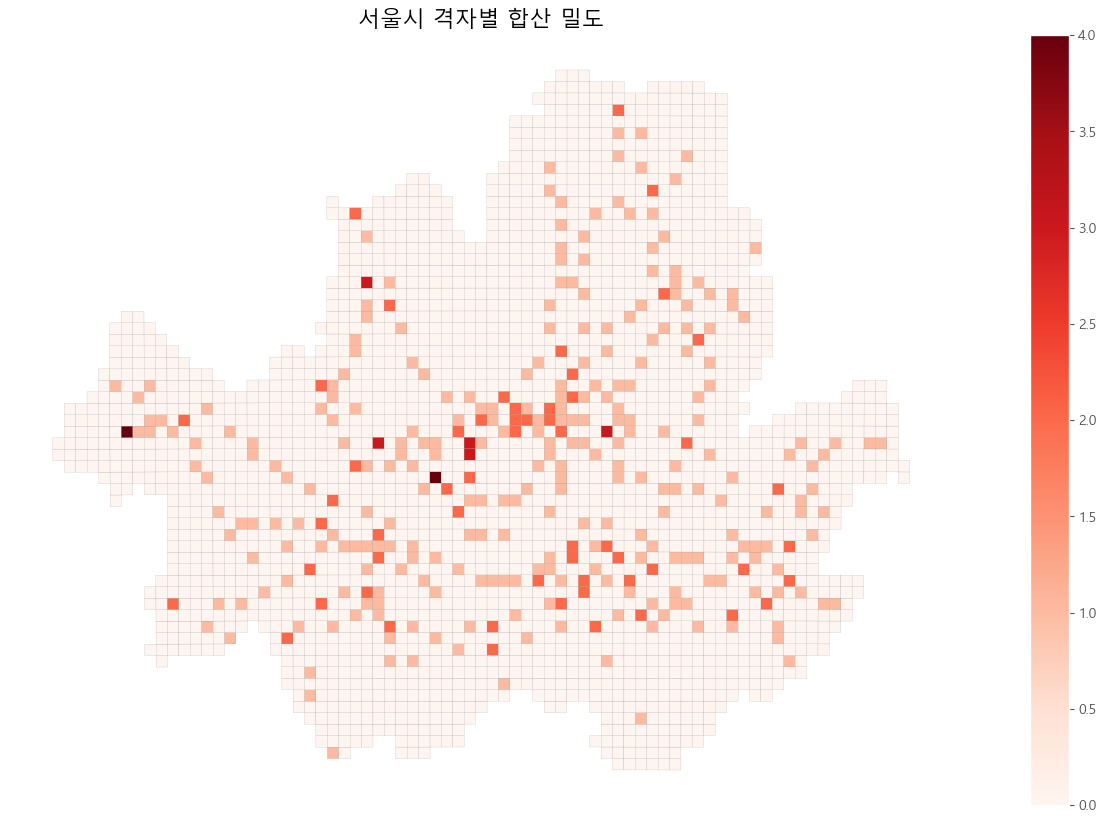

In [52]:
import matplotlib.pyplot as plt

# 시각화를 위한 Figure와 Axes를 준비합니다.
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# 'bus_count' 컬럼의 값에 따라 색상을 다르게 하여 지도를 그립니다.
grid_with_counts.plot(column='metro_count', # 색상을 결정할 기준 컬럼
                      cmap='Reds',      # 사용할 색상 맵 (예: 'Reds', 'Blues', 'Oranges')
                      linewidth=0.1,         # 격자 테두리 선 두께
                      edgecolor='grey',      # 격자 테두리 색상
                      legend=True,           # 범례 표시
                      ax=ax)

# 지도 제목을 추가하고 축은 보이지 않게 처리합니다.
ax.set_title('서울시 격자별 합산 밀도', fontsize=16)
ax.set_axis_off()

# 지도를 화면에 보여줍니다.
plt.show()

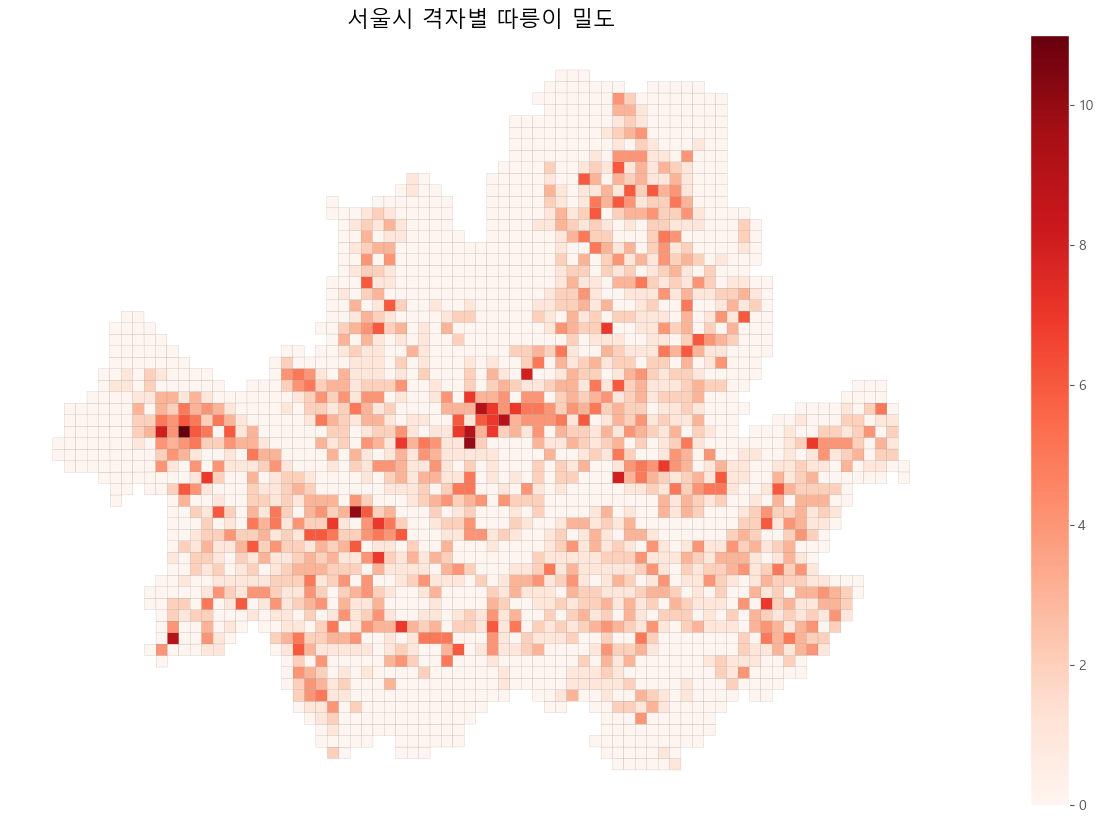

In [53]:
import matplotlib.pyplot as plt

# 시각화를 위한 Figure와 Axes를 준비합니다.
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# 'bus_count' 컬럼의 값에 따라 색상을 다르게 하여 지도를 그립니다.
grid_with_counts.plot(column='bike_count', # 색상을 결정할 기준 컬럼
                      cmap='Reds',      # 사용할 색상 맵 (예: 'Reds', 'Blues', 'Oranges')
                      linewidth=0.1,         # 격자 테두리 선 두께
                      edgecolor='grey',      # 격자 테두리 색상
                      legend=True,           # 범례 표시
                      ax=ax)

# 지도 제목을 추가하고 축은 보이지 않게 처리합니다.
ax.set_title('서울시 격자별 따릉이 밀도', fontsize=16)
ax.set_axis_off()

# 지도를 화면에 보여줍니다.
plt.show()

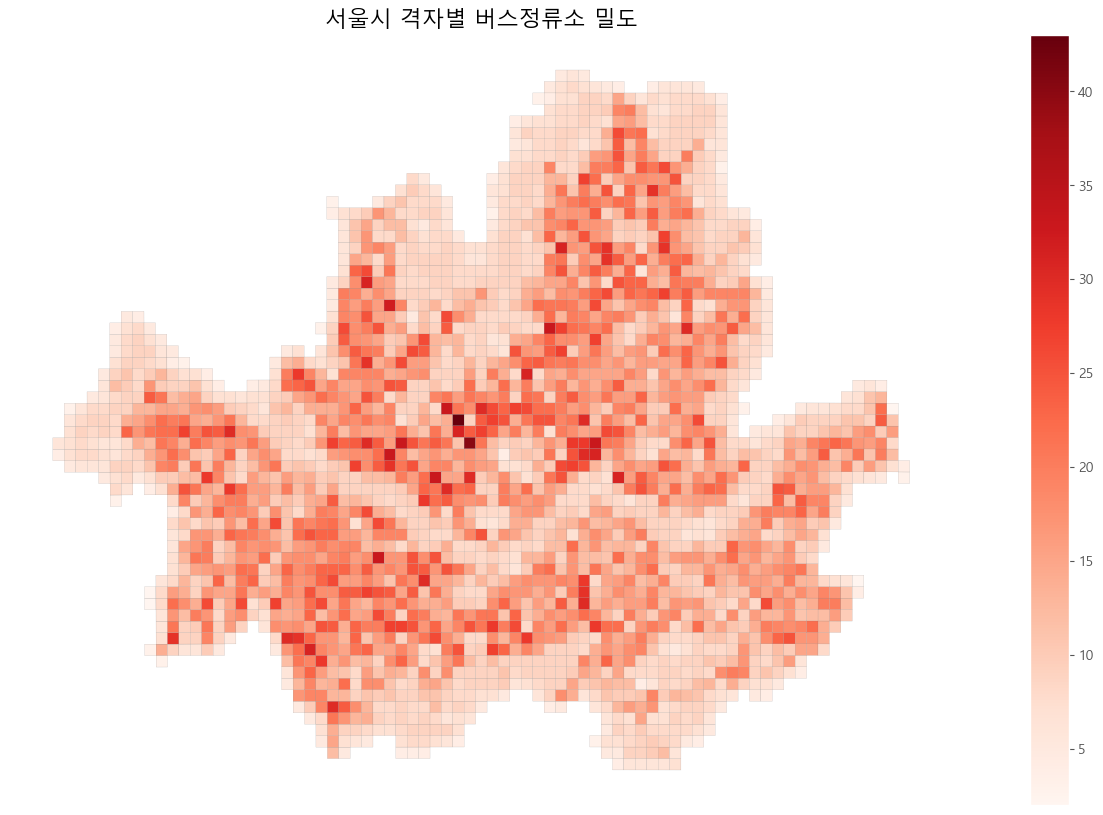

In [54]:
import matplotlib.pyplot as plt

# 시각화를 위한 Figure와 Axes를 준비합니다.
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# 'bus_count' 컬럼의 값에 따라 색상을 다르게 하여 지도를 그립니다.
grid_with_counts.plot(column='total_count', # 색상을 결정할 기준 컬럼
                      cmap='Reds',      # 사용할 색상 맵 (예: 'Reds', 'Blues', 'Oranges')
                      linewidth=0.1,         # 격자 테두리 선 두께
                      edgecolor='grey',      # 격자 테두리 색상
                      legend=True,           # 범례 표시
                      ax=ax)

# 지도 제목을 추가하고 축은 보이지 않게 처리합니다.
ax.set_title('서울시 격자별 버스정류소 밀도', fontsize=16)
ax.set_axis_off()

# 지도를 화면에 보여줍니다.
plt.show()

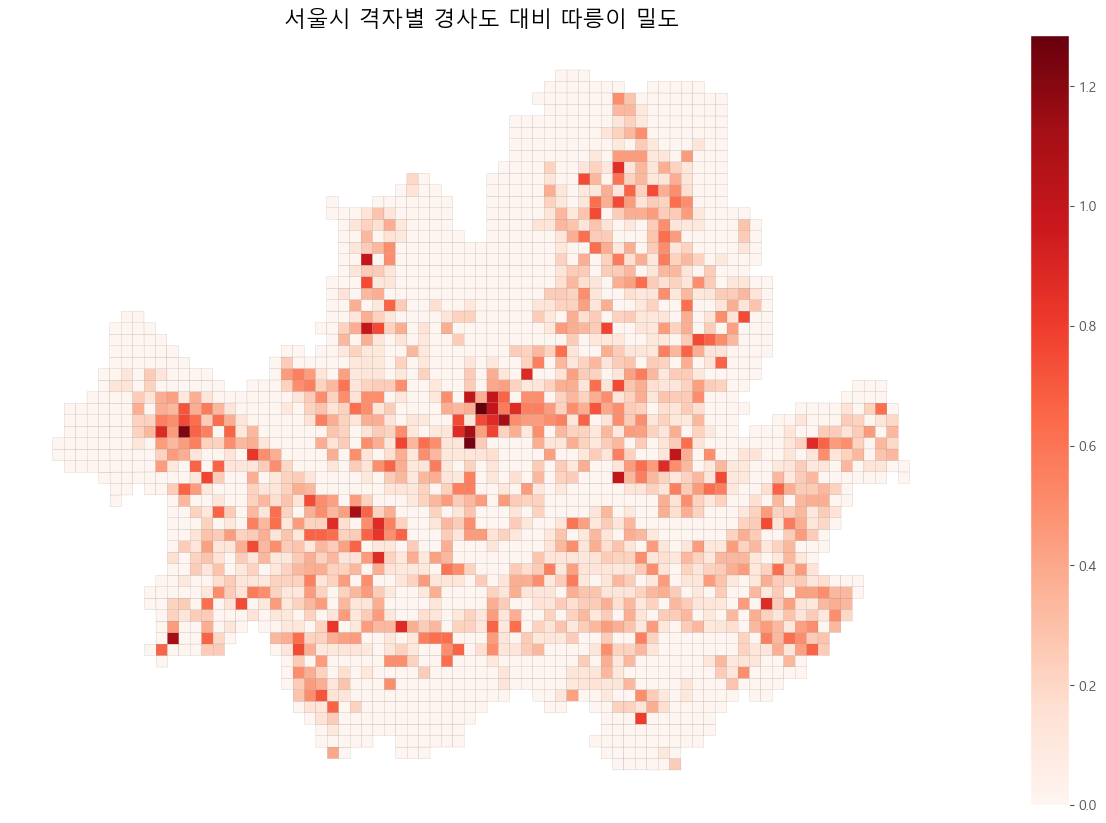

In [55]:
import matplotlib.pyplot as plt

# 시각화를 위한 Figure와 Axes를 준비합니다.
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# 'bus_count' 컬럼의 값에 따라 색상을 다르게 하여 지도를 그립니다.
grid_with_counts.plot(column='slope_bike_count', # 색상을 결정할 기준 컬럼
                      cmap='Reds',      # 사용할 색상 맵 (예: 'Reds', 'Blues', 'Oranges')
                      linewidth=0.1,         # 격자 테두리 선 두께
                      edgecolor='grey',      # 격자 테두리 색상
                      legend=True,           # 범례 표시
                      ax=ax)

# 지도 제목을 추가하고 축은 보이지 않게 처리합니다.
ax.set_title('서울시 격자별 경사도 대비 따릉이 밀도', fontsize=16)
ax.set_axis_off()

# 지도를 화면에 보여줍니다.
plt.show()

## slope 적용

In [56]:
slope_shp['slope_mean'].describe()

count    2639.000000
mean        4.868649
std         5.239078
min         0.016756
25%         1.006176
50%         2.708179
75%         7.106035
max        27.785015
Name: slope_mean, dtype: float64

In [ ]:
# 원본 격자 데이터(경사도 정보 포함)를 복사하여 사용합니다.
# 'geo_shp'에 slope_mean과 geometry가 모두 있다고 가정합니다.
final_grid = slope_shp.copy()

# 1. 버스 개수 합치기
final_grid = final_grid.merge(bus_counts_df, left_on=final_grid.index, right_on='index_right', how='left')
final_grid = final_grid.drop('index_right', axis=1) # 불필요한 열 삭제

# 2. 따릉이 개수 합치기
final_grid = final_grid.merge(bike_counts_df, left_on=final_grid.index, right_on='index_right', how='left')
final_grid = final_grid.drop('index_right', axis=1)

# 3. 지하철 개수 합치기
final_grid = final_grid.merge(metro_counts_df, left_on=final_grid.index, right_on='index_right', how='left')
final_grid = final_grid.drop('index_right', axis=1)

# 4. 개수가 없는 격자(NaN)는 0으로 채우기
count_cols = ['bus_count', 'bike_count', 'metro_count']
final_grid[count_cols] = final_grid[count_cols].fillna(0)

print("--- 모든 개수 정보가 통합된 데이터 ---")
final_grid.head()

--- 모든 개수 정보가 통합된 데이터 ---


,cx,cy,slope_mean,geometry,bus_count,bike_count,metro_count
0,179439.7616,450297.4067,18.125252,"POLYGON ((126.7645 37.54971, 126.76449 37.5542...",0.0,0.0,0.0
1,179439.7616,450797.4067,18.221235,"POLYGON ((126.76449 37.55422, 126.76447 37.558...",2.0,0.0,0.0
2,179939.7616,449797.4067,0.665497,"POLYGON ((126.77017 37.54522, 126.77016 37.549...",0.0,0.0,0.0
3,179939.7616,450297.4067,0.144283,"POLYGON ((126.77016 37.54972, 126.77015 37.554...",0.0,0.0,0.0
4,179939.7616,450797.4067,0.151225,"POLYGON ((126.77015 37.55423, 126.77013 37.558...",0.0,0.0,0.0


In [58]:
import numpy as np

# 경사도에 따른 페널티 가중치(등급)를 정의합니다.
conditions = [
    (final_grid['slope_mean'] <= 3),  # 평지
    (final_grid['slope_mean'] > 3) & (final_grid['slope_mean'] <= 7),  # 완경사
    (final_grid['slope_mean'] > 7)   # 급경사
]
# 평지는 100% 가치, 완경사는 60%, 급경사는 20%의 가치만 인정
weights = [1.0, 0.6, 0.2]

# 'slope_weight' 컬럼에 각 격자의 경사도 가중치를 할당
final_grid['slope_weight'] = np.select(conditions, weights, default=0)

# '조정된 따릉이 점수' = (기존 따릉이 개수) * (경사도 가중치)
final_grid['adjusted_bike_score'] = final_grid['bike_count'] * final_grid['slope_weight']

print("\n--- 경사도가 반영된 따릉이 점수 ---")
final_grid.head()


--- 경사도가 반영된 따릉이 점수 ---


,cx,cy,slope_mean,geometry,bus_count,bike_count,metro_count,slope_weight,adjusted_bike_score
0,179439.7616,450297.4067,18.125252,"POLYGON ((126.7645 37.54971, 126.76449 37.5542...",0.0,0.0,0.0,0.2,0.0
1,179439.7616,450797.4067,18.221235,"POLYGON ((126.76449 37.55422, 126.76447 37.558...",2.0,0.0,0.0,0.2,0.0
2,179939.7616,449797.4067,0.665497,"POLYGON ((126.77017 37.54522, 126.77016 37.549...",0.0,0.0,0.0,1.0,0.0
3,179939.7616,450297.4067,0.144283,"POLYGON ((126.77016 37.54972, 126.77015 37.554...",0.0,0.0,0.0,1.0,0.0
4,179939.7616,450797.4067,0.151225,"POLYGON ((126.77015 37.55423, 126.77013 37.558...",0.0,0.0,0.0,1.0,0.0


In [59]:
# 각 교통수단별 중요도(가중치) 설정 (예시)
#w_metro = 1  # 지하철은 가장 중요하므로 1.5점
#w_bus = 1    # 버스는 기본 점수인 1.0점
#w_bike = 1   # 따릉이는 보조 수단이므로 0.5점

# 최종 교통 편의성 지수 계산
#final_grid['transport_score'] = (final_grid['metro_count'] * w_metro) + \
   #                             (final_grid['bus_count'] * w_bus) + \
   #                             (final_grid['adjusted_bike_score'] * w_bike) # 조정된 따릉이 점수 사용!

# (선택) 점수를 0~100점으로 정규화하여 비교하기 쉽게 만들기
#score = final_grid['transport_score']
#final_grid['transport_score_normalized'] = ((score - score.min()) / (score.max() - score.min())) * 100

#print("\n--- 최종 교통 편의성 지수 ---")
#final_grid.sort_values(by='transport_score', ascending=False).head()

## 시각화

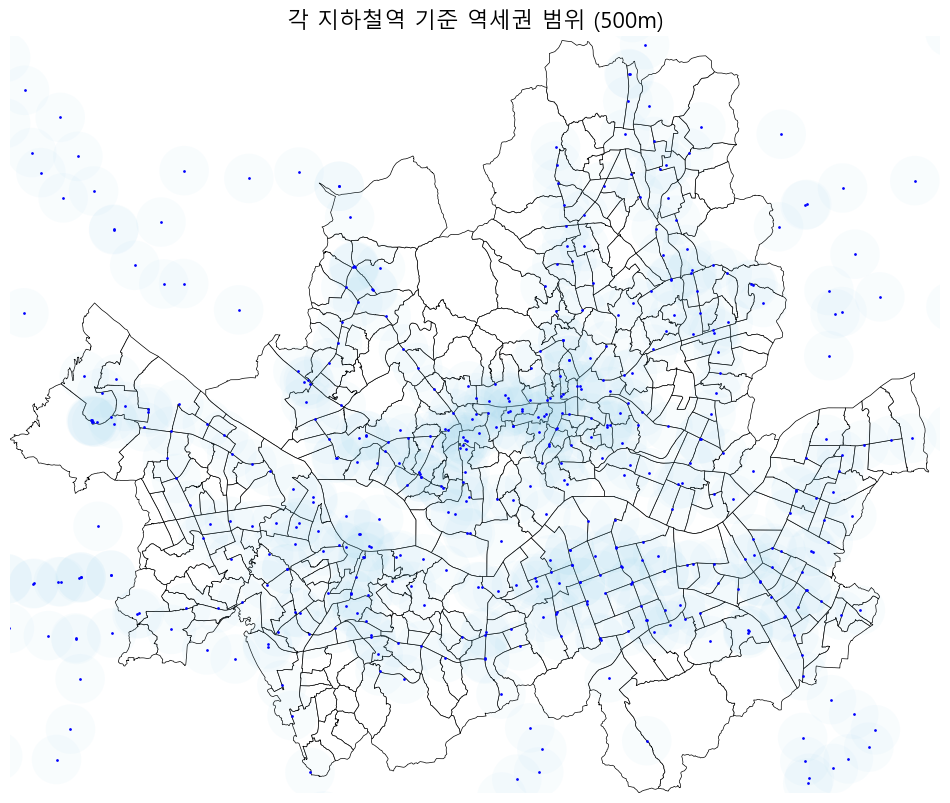

In [34]:
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point
import matplotlib.pyplot as plt


geo_shp_wgs84 = gpd.read_file("seoul_grid_500m.shp")
geo_shp = geo_shp_wgs84.to_crs("EPSG:5179")
seoul_wgs84 = gpd.read_file("C:/Users/jeongmin/Downloads/vscode/서울시 상권분석서비스(영역-행정동)/서울시 상권분석서비스(영역-행정동).shp")
seoul = seoul_wgs84.to_crs("EPSG:5179")

# --- 지하철 데이터 처리 ---
df_metro = pd.read_csv("서울시 역사마스터 정보.csv", encoding='cp949')
df_metro = df_metro.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_metro["geometry"] = df_metro.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_metro_wgs84 = GeoDataFrame(df_metro, crs="EPSG:4326", geometry="geometry")
geo_metro = geo_metro_wgs84.to_crs("EPSG:5179")


# --- 3. 최종 시각화 (수정된 부분) ---
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
seoul.plot(ax=ax, color='white', edgecolor='black', zorder=1)

metro_buffers = geo_metro.buffer(1000)
metro_buffers.plot(ax=ax, color='skyblue', alpha=0.05, edgecolor='none', label='역세권 (반경 1km)')
geo_metro.plot(ax=ax, marker='o', color='blue', markersize=2)

ax.set_title('각 지하철역 기준 역세권 범위 (500m)', fontsize=16)
ax.set_axis_off()
minx, miny, maxx, maxy = geo_shp.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.show()

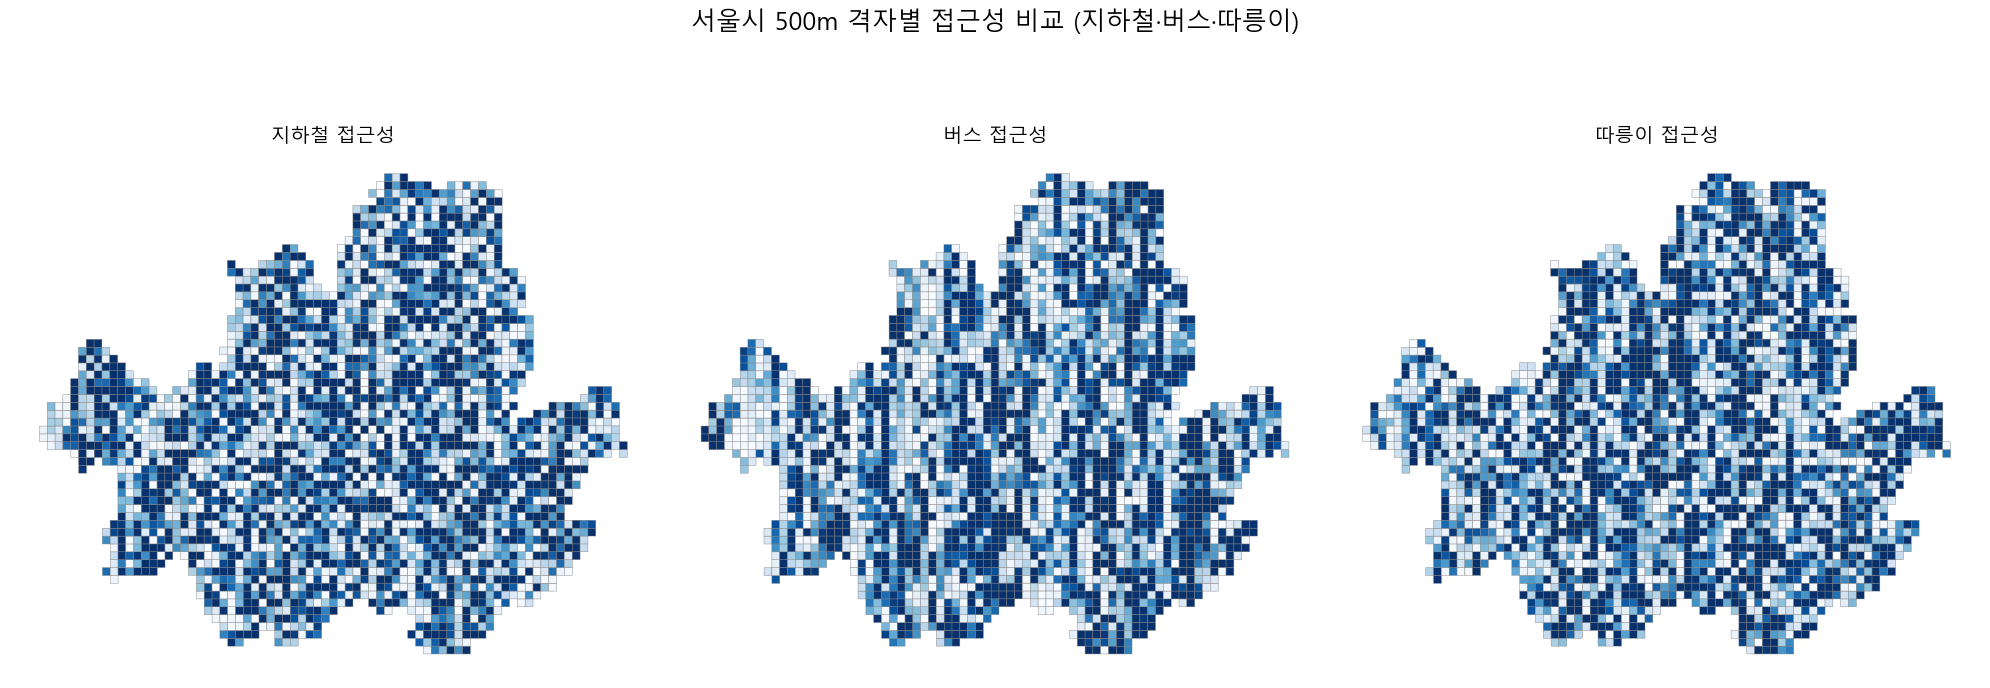

In [84]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

geo_shp_wgs84 = gpd.read_file("seoul_grid_500m.shp")
geo_shp = geo_shp_wgs84.to_crs("EPSG:5179")
seoul_wgs84 = gpd.read_file("C:/Users/jeongmin/Downloads/vscode/서울시 상권분석서비스(영역-행정동)/서울시 상권분석서비스(영역-행정동).shp")
seoul = seoul_wgs84.to_crs("EPSG:5179")


def compute_buffer_ratio(geo_points, buffer_radius=1000):
    """점 데이터를 기준으로 버퍼를 만들고, 격자별 커버율 계산"""
    buffers = gpd.GeoDataFrame(geometry=geo_points.buffer(buffer_radius), crs=geo_shp.crs)
    intersect = gpd.overlay(geo_shp, buffers, how="intersection")
    intersect["area"] = intersect.geometry.area
    area_sum = intersect.groupby(intersect.index)["area"].sum()
    ratio = area_sum / geo_shp.geometry.area
    return ratio.fillna(0)

# 지하철역
df_metro = pd.read_csv("서울시 역사마스터 정보.csv", encoding="cp949")
df_metro = df_metro.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_metro["geometry"] = df_metro.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_metro = gpd.GeoDataFrame(df_metro, crs="EPSG:4326", geometry="geometry").to_crs("EPSG:5179")
geo_metro = gpd.sjoin(geo_metro, seoul, predicate="within").drop(columns=["index_right"])
geo_shp["metro_ratio"] = compute_buffer_ratio(geo_metro)

# 버스정류장
df_bus = pd.read_csv("서울시 버스정류소 위치정보.csv", encoding="cp949")
df_bus = df_bus.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_bus["geometry"] = df_bus.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_bus = gpd.GeoDataFrame(df_bus, crs="EPSG:4326", geometry="geometry").to_crs("EPSG:5179")
geo_bus = gpd.sjoin(geo_bus, seoul, predicate="within").drop(columns=["index_right"])
geo_shp["bus_ratio"] = compute_buffer_ratio(geo_bus)

# 따릉이 대여소
df_bic = pd.read_csv("서울시 따릉이대여소 마스터 정보.csv", encoding="cp949")
df_bic = df_bic.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_bic["geometry"] = df_bic.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_bic = gpd.GeoDataFrame(df_bic, crs="EPSG:4326", geometry="geometry").to_crs("EPSG:5179")
geo_bic = gpd.sjoin(geo_bic, seoul, predicate="within").drop(columns=["index_right"])
geo_shp["bic_ratio"] = compute_buffer_ratio(geo_bic)
import numpy as np


geo_shp = geo_shp.to_crs("EPSG:4326")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
cols = ["metro_ratio", "bus_ratio", "bic_ratio"]
titles = ["지하철 접근성", "버스 접근성", "따릉이 접근성"]

for i, ax in enumerate(axes):
    geo_shp.plot(ax=ax, column=cols[i], cmap="Blues", legend=False, edgecolor="gray", linewidth=0.3)
    #seoul.to_crs("EPSG:4326").boundary.plot(ax=ax, color="black", linewidth=0.5)
    ax.set_title(titles[i], fontsize=14)
    ax.set_axis_off()

plt.suptitle("서울시 500m 격자별 접근성 비교 (지하철·버스·따릉이)", fontsize=18)
plt.tight_layout()
plt.show()


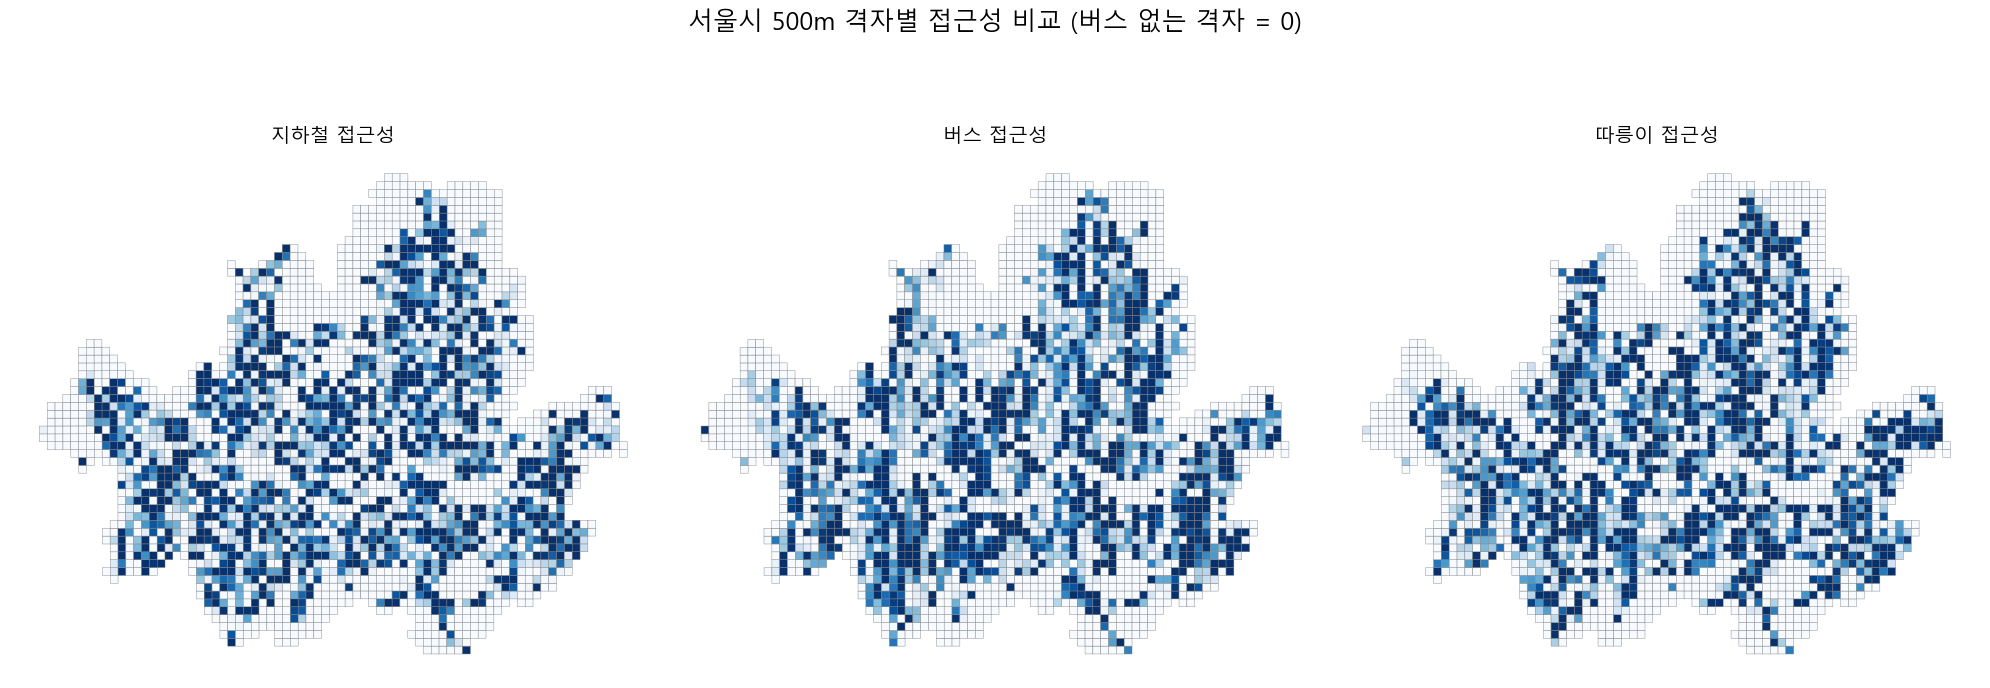

In [85]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt


geo_shp_wgs84 = gpd.read_file("seoul_grid_500m.shp")
geo_shp = geo_shp_wgs84.to_crs("EPSG:5179")
seoul_wgs84 = gpd.read_file("C:/Users/jeongmin/Downloads/vscode/서울시 상권분석서비스(영역-행정동)/서울시 상권분석서비스(영역-행정동).shp"
)
seoul = seoul_wgs84.to_crs("EPSG:5179")

def compute_buffer_ratio(geo_points, buffer_radius=1000):
    """점 데이터를 기준으로 버퍼를 만들고, 격자별 커버율 계산"""
    buffers = gpd.GeoDataFrame(geometry=geo_points.buffer(buffer_radius), crs=geo_shp.crs)
    intersect = gpd.overlay(geo_shp, buffers, how="intersection")
    intersect["area"] = intersect.geometry.area
    area_sum = intersect.groupby(intersect.index)["area"].sum()
    ratio = area_sum / geo_shp.geometry.area
    return ratio.fillna(0)

# 지하철
df_metro = pd.read_csv("서울시 역사마스터 정보.csv", encoding="cp949")
df_metro = df_metro.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_metro["geometry"] = df_metro.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_metro = gpd.GeoDataFrame(df_metro, crs="EPSG:4326", geometry="geometry").to_crs("EPSG:5179")
geo_metro = gpd.sjoin(geo_metro, seoul, predicate="within").drop(columns=["index_right"])
geo_shp["metro_ratio"] = compute_buffer_ratio(geo_metro)

# 버스정류장
df_bus = pd.read_csv("서울시 버스정류소 위치정보.csv", encoding="cp949")
df_bus = df_bus.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_bus["geometry"] = df_bus.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_bus = gpd.GeoDataFrame(df_bus, crs="EPSG:4326", geometry="geometry").to_crs("EPSG:5179")
geo_bus = gpd.sjoin(geo_bus, seoul, predicate="within").drop(columns=["index_right"])
geo_shp["bus_ratio"] = compute_buffer_ratio(geo_bus)

# 따릉이
df_bic = pd.read_csv("서울시 따릉이대여소 마스터 정보.csv", encoding="cp949")
df_bic = df_bic.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_bic["geometry"] = df_bic.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_bic = gpd.GeoDataFrame(df_bic, crs="EPSG:4326", geometry="geometry").to_crs("EPSG:5179")
geo_bic = gpd.sjoin(geo_bic, seoul, predicate="within").drop(columns=["index_right"])
geo_shp["bic_ratio"] = compute_buffer_ratio(geo_bic)

# ──────────────────────────────
#  버스 없는 격자 식별 후 → 전부 0으로
# ──────────────────────────────
# 버스가 존재하는 격자 찾기
bus_join = gpd.sjoin(geo_shp, geo_bus, predicate="contains", how="left")
bus_presence = bus_join.groupby(bus_join.index)["index_right"].count()
# 버스 없는 격자 인덱스 추출
no_bus_idx = bus_presence[bus_presence == 0].index
# 버스가 없는 곳은 전부 0으로 강제 설정
geo_shp.loc[no_bus_idx, ["bus_ratio", "metro_ratio", "bic_ratio"]] = 0


geo_shp = geo_shp.to_crs("EPSG:4326")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
cols = ["metro_ratio", "bus_ratio", "bic_ratio"]
titles = ["지하철 접근성", "버스 접근성", "따릉이 접근성"]

for i, ax in enumerate(axes):
    geo_shp.plot(ax=ax, column=cols[i], cmap="Blues", legend=False, edgecolor="gray", linewidth=0.3)
    ax.set_title(titles[i], fontsize=14)
    ax.set_axis_off()

plt.suptitle("서울시 500m 격자별 접근성 비교 (버스 없는 격자 = 0)", fontsize=18)
plt.tight_layout()
plt.show()


In [77]:
geo_shp

,cx,cy,geometry,metro_ratio,bus_ratio,bic_ratio
0,179439.7616,450297.4067,"POLYGON ((126.7645 37.54971, 126.76449 37.5542...",0.000000,0.000000,0.000000
1,179439.7616,450797.4067,"POLYGON ((126.76449 37.55422, 126.76447 37.558...",0.073686,1.000000,0.183785
2,179939.7616,449797.4067,"POLYGON ((126.77017 37.54522, 126.77016 37.549...",0.000000,0.000000,0.000000
3,179939.7616,450297.4067,"POLYGON ((126.77016 37.54972, 126.77015 37.554...",0.000000,0.000000,0.000000
4,179939.7616,450797.4067,"POLYGON ((126.77015 37.55423, 126.77013 37.558...",0.000000,0.000000,0.000000
...,...,...,...,...,...,...
2634,215939.7616,451297.4067,"POLYGON ((127.17757 37.55882, 127.17758 37.563...",0.004238,0.302283,1.000067
2635,215939.7616,451797.4067,"POLYGON ((127.17758 37.56333, 127.1776 37.5678...",1.000044,0.699907,0.277752
2636,215939.7616,452297.4067,"POLYGON ((127.1776 37.56783, 127.17761 37.5723...",0.000000,0.000000,0.000000
2637,216439.7616,449297.4067,"POLYGON ((127.18319 37.54079, 127.1832 37.5453...",0.000000,0.000000,0.000000


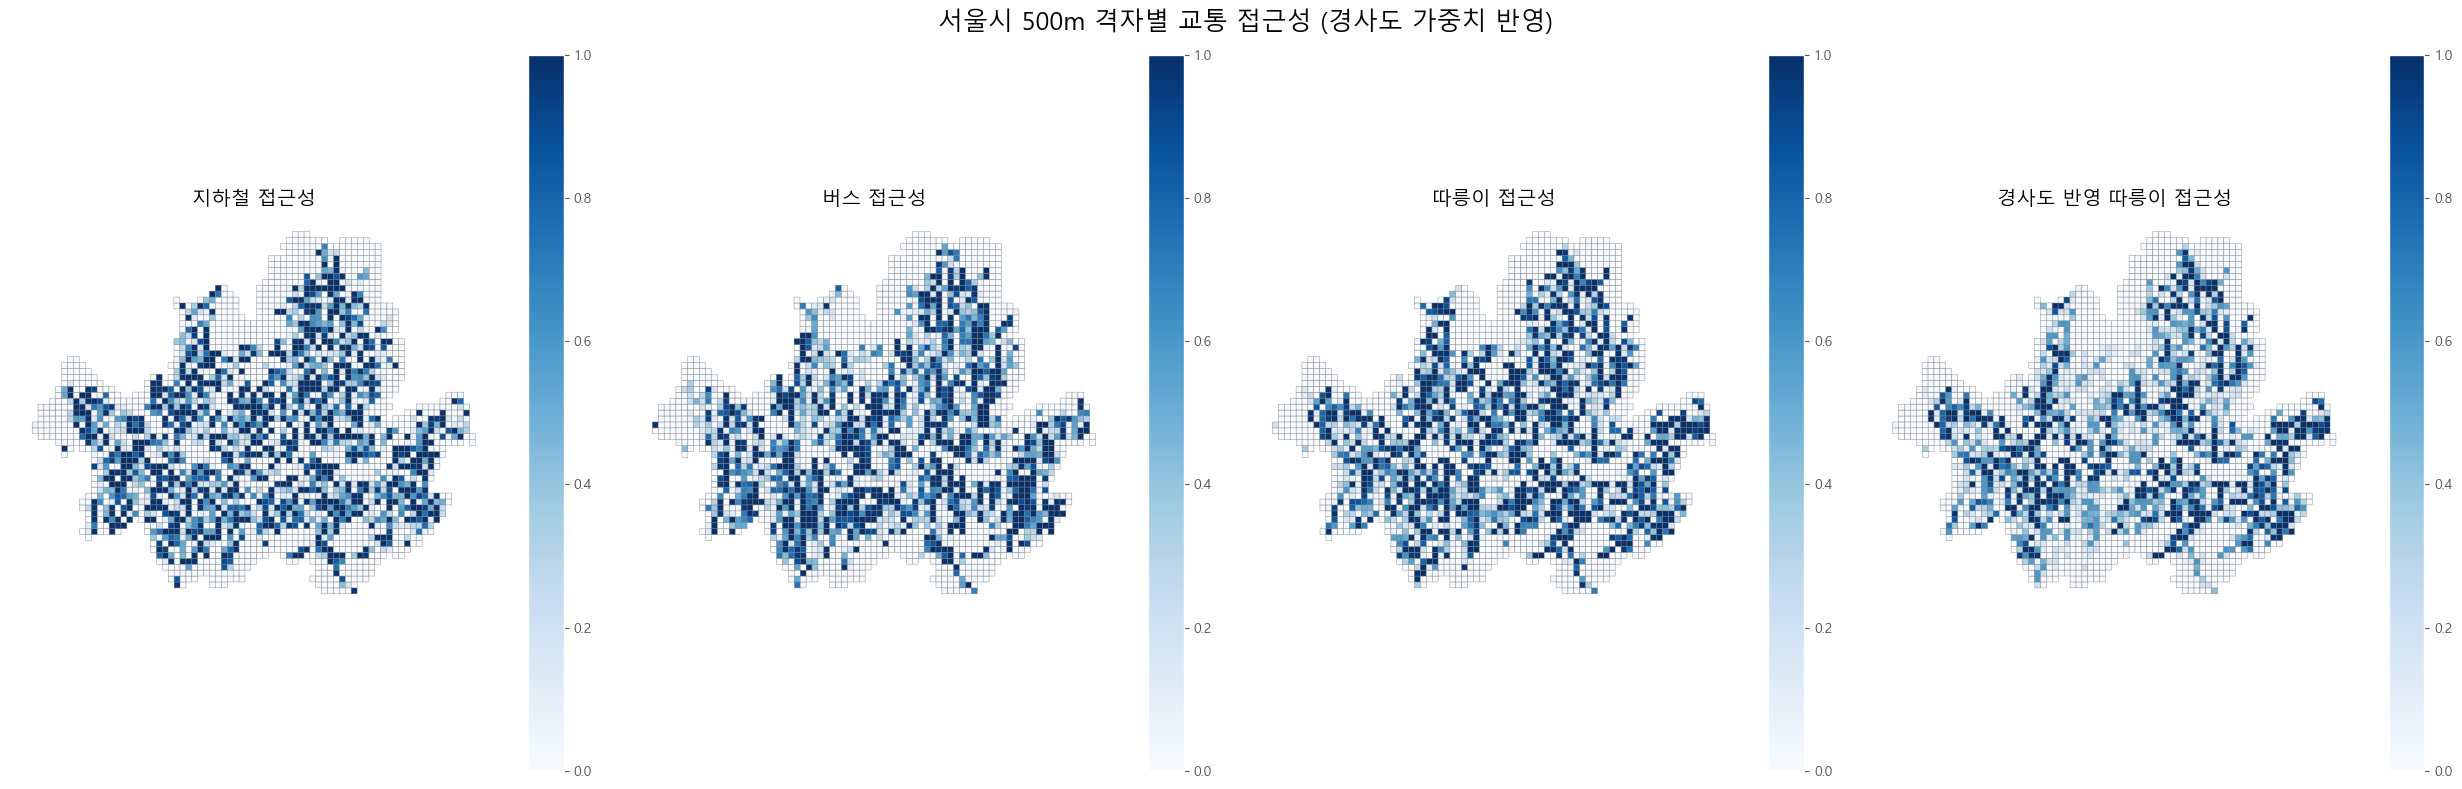

In [86]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np

geo_shp_wgs84 = gpd.read_file("seoul_grid_500m.shp")
geo_shp = geo_shp_wgs84.to_crs("EPSG:5179")
seoul_wgs84 = gpd.read_file("C:/Users/jeongmin/Downloads/vscode/서울시 상권분석서비스(영역-행정동)/서울시 상권분석서비스(영역-행정동).shp")
seoul = seoul_wgs84.to_crs("EPSG:5179")

def compute_buffer_ratio(geo_points, buffer_radius=1000):
    """점 데이터를 기준으로 버퍼를 만들고, 격자별 커버율 계산"""
    buffers = gpd.GeoDataFrame(geometry=geo_points.buffer(buffer_radius), crs=geo_shp.crs)
    intersect = gpd.overlay(geo_shp, buffers, how="intersection")
    intersect["area"] = intersect.geometry.area
    area_sum = intersect.groupby(intersect.index)["area"].sum()
    ratio = area_sum / geo_shp.geometry.area
    return ratio.fillna(0)

# 지하철
df_metro = pd.read_csv("서울시 역사마스터 정보.csv", encoding="cp949")
df_metro = df_metro.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_metro["geometry"] = df_metro.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_metro = gpd.GeoDataFrame(df_metro, crs="EPSG:4326", geometry="geometry").to_crs("EPSG:5179")
geo_metro = gpd.sjoin(geo_metro, seoul, predicate="within").drop(columns=["index_right"])
geo_shp["metro_ratio"] = compute_buffer_ratio(geo_metro)

# 버스정류장
df_bus = pd.read_csv("서울시 버스정류소 위치정보.csv", encoding="cp949")
df_bus = df_bus.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_bus["geometry"] = df_bus.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_bus = gpd.GeoDataFrame(df_bus, crs="EPSG:4326", geometry="geometry").to_crs("EPSG:5179")
geo_bus = gpd.sjoin(geo_bus, seoul, predicate="within").drop(columns=["index_right"])
geo_shp["bus_ratio"] = compute_buffer_ratio(geo_bus)

# 따릉이
df_bic = pd.read_csv("서울시 따릉이대여소 마스터 정보.csv", encoding="cp949")
df_bic = df_bic.rename(columns={"X좌표": "경도", "Y좌표": "위도"})
df_bic["geometry"] = df_bic.apply(lambda x: Point(x["경도"], x["위도"]), axis=1)
geo_bic = gpd.GeoDataFrame(df_bic, crs="EPSG:4326", geometry="geometry").to_crs("EPSG:5179")
geo_bic = gpd.sjoin(geo_bic, seoul, predicate="within").drop(columns=["index_right"])
geo_shp["bic_ratio"] = compute_buffer_ratio(geo_bic)

# ──────────────────────────────
# 버스 없는 격자 → 접근성 0
# ──────────────────────────────
bus_join = gpd.sjoin(geo_shp, geo_bus, predicate="contains", how="left")
bus_presence = bus_join.groupby(bus_join.index)["index_right"].count()
no_bus_idx = bus_presence[bus_presence == 0].index
geo_shp.loc[no_bus_idx, ["bus_ratio", "metro_ratio", "bic_ratio"]] = 0

# ──────────────────────────────
# 경사도 가중치 반영
# ──────────────────────────────
slope_shp = gpd.read_file("slope_seoul.shp").to_crs("EPSG:5179")

geo_shp = geo_shp.merge(
    slope_shp.drop(columns="geometry"),
    left_index=True,
    right_index=True,
    how="left"
)

conditions = [
    (geo_shp["slope_mean"] <= 3),     # 평지
    (geo_shp["slope_mean"] > 3) & (geo_shp["slope_mean"] <= 7),  # 완경사
    (geo_shp["slope_mean"] > 7)       # 급경사
]
weights = [1.0, 0.6, 0.2]

geo_shp["slope_weight"] = np.select(conditions, weights, default=0)
geo_shp["bic_ratio_weighted"] = geo_shp["bic_ratio"] * geo_shp["slope_weight"]



geo_shp = geo_shp.to_crs("EPSG:4326")

fig, axes = plt.subplots(1, 4, figsize=(25, 8))
cols = ["metro_ratio", "bus_ratio", "bic_ratio", "bic_ratio_weighted"]
titles = ["지하철 접근성", "버스 접근성", "따릉이 접근성", "경사도 반영 따릉이 접근성"]

for i, ax in enumerate(axes):
    geo_shp.plot(ax=ax, column=cols[i], cmap="Blues", legend=True, edgecolor="gray", linewidth=0.3)
    ax.set_title(titles[i], fontsize=14)
    ax.set_axis_off()

plt.suptitle("서울시 500m 격자별 교통 접근성 (경사도 가중치 반영)", fontsize=18)
plt.tight_layout()
plt.show()

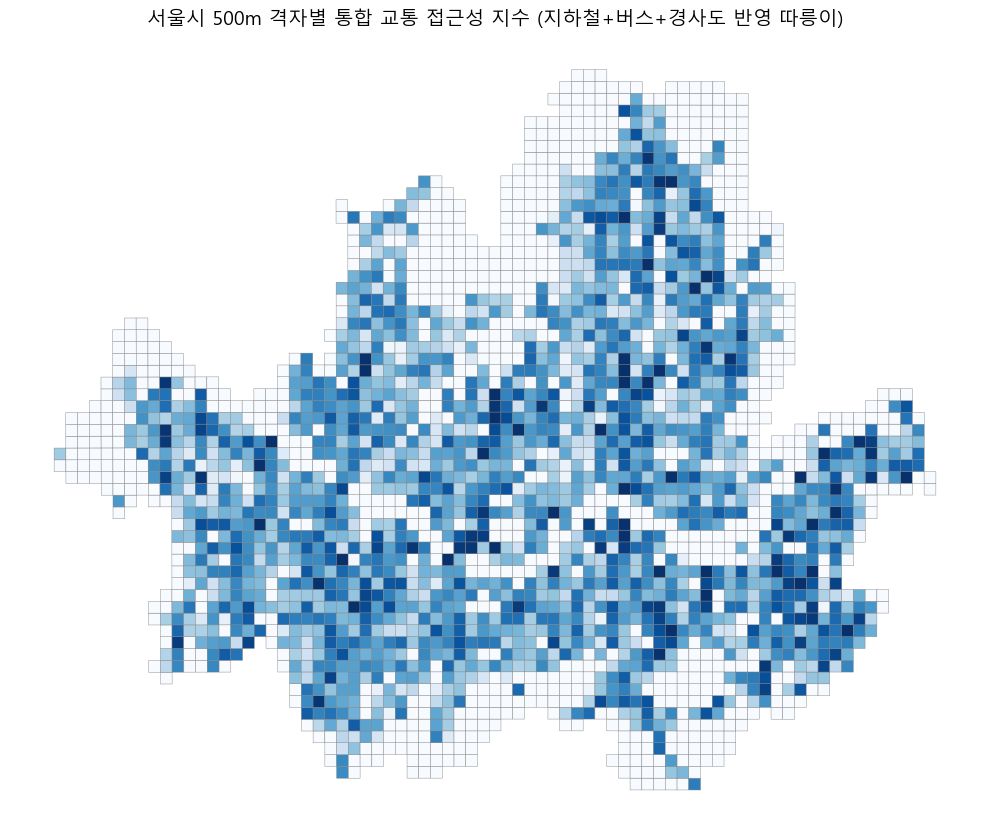

In [89]:
geo_shp["total_access"] = (
    geo_shp["metro_ratio"] +
    geo_shp["bus_ratio"] +
    geo_shp["bic_ratio_weighted"]
)

# 필요하면 정규화 (0~1 구간)
# geo_shp["total_access"] = (
#     (geo_shp["total_access"] - geo_shp["total_access"].min()) /
#     (geo_shp["total_access"].max() - geo_shp["total_access"].min())
# )

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
geo_shp.plot(
    ax=ax,
    column="total_access",
    cmap="Blues",
    legend=False,
    edgecolor="gray",
    linewidth=0.3
)

ax.set_title("서울시 500m 격자별 통합 교통 접근성 지수 (지하철+버스+경사도 반영 따릉이)", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [92]:
geo_shp.to_file("교통지수최종.shp")

C:\Users\jeongmin\AppData\Local\Temp\ipykernel_23632\2607747486.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  geo_shp.to_file("교통지수최종.shp")
c:\Users\jeongmin\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'metro_ratio' to 'metro_rati'
  ogr_write(
c:\Users\jeongmin\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'slope_weight' to 'slope_weig'
  ogr_write(
c:\Users\jeongmin\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'bic_ratio_weighted' to 'bic_ratio_'
  ogr_write(
c:\Users\jeongmin\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'total_access' to 'total_acce'
  ogr_write(
